# **Modelo Aditivo Neuronal (NAM)**

* **NOTA**: *correr en $\texttt{colab}$ en un entorno de ejecución $\textsf{GPU T4}$.*

* Ver documentacion de `dnamite` en https://dnamite.readthedocs.io/en/latest/




# Instalar *dnamite* para ajustar Modelo Aditivo Neuronal (NAM)

In [ ]:
!pip install --upgrade scikit-learn scipy dnamite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 68.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.9/52.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
from sklearn.model_selection import train_test_split
import torch
import os

In [ ]:
# Configurar el dispositivo de ejecución (GPU si está disponible para acelerar el entrenamiento)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
seed = 1
print(device)

cuda:0


# Datos

In [ ]:
# Datos con los nombres de columna correspondientes
columnas = ["age", "workclass", "fnlwgt", "education", "education_num",
            "marital_status", "occupation", "relationship", "race",
            "sex", "capital_gain", "capital_loss", "hours_per_week",
            "native_country", "Ingreso"]

# Cargar el dataset
adult = pd.read_csv("/content/drive/MyDrive/NAM/adult.csv", names=columnas, header=0)

# Separar características (X) y respuesta (y) sin alterar las categóricas
X = adult.drop(columns=["Ingreso"])

# Convertir la variable objetivo a binaria (1 si gana >50K, 0 en caso contrario)
# Se aplica .str.strip() por si los valores del archivo conservan espacios en blanco
y = (adult["Ingreso"].str.strip() == ">50K").astype(int)

In [ ]:
# Partición de datos en entrenamiento, validación y prueba

# Indices usados en los modelos MLP, GLM Y GAM
train_idx = pd.read_csv("/content/drive/MyDrive/NAM/train_idx.csv").iloc[:,0]
val_idx   = pd.read_csv("/content/drive/MyDrive/NAM/val_idx.csv").iloc[:,0]
test_idx  = pd.read_csv("/content/drive/MyDrive/NAM/test_idx.csv").iloc[:,0]

# En Python los indices inician en 0
train_idx = train_idx - 1
val_idx   = val_idx - 1
test_idx  = test_idx - 1

# Partición

X_train = X.iloc[train_idx].copy()
X_val   = X.iloc[val_idx].copy()
X_test  = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val   = y.iloc[val_idx].copy()
y_test  = y.iloc[test_idx].copy()

# Variables categóricas

In [ ]:
# Ver tipos de variables
print(X_train.dtypes)
print(X_train.shape)

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
dtype: object
(29305, 14)


In [ ]:
# Columnas categóricas
cat_cols = X_train.select_dtypes(include="object").columns

# Convertir a tipo category
X_train[cat_cols] = X_train[cat_cols].astype("category")
X_val[cat_cols]   = X_val[cat_cols].astype("category")
X_test[cat_cols]  = X_test[cat_cols].astype("category")

In [ ]:
# Ver tamaños

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(29305, 14)
(9768, 14)
(9769, 14)


# Modelo NAM

In [ ]:
from dnamite.models import DNAMiteBinaryClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
# Modelo sin interacciones: "num_pairs=0" (3 min.)

model = DNAMiteBinaryClassifier(
    random_state=1,
    device=device,
    num_pairs=0
)

model.fit(X_train, y_train)

preds = model.predict_proba(X_test)

auc = roc_auc_score(y_test, preds)
print("AUC:", round(auc, 4))

AUC: 0.929


# Selección de variables

In [ ]:
# Elegir parametro de regularizacion por AUC (14 min.)

resultados = []

for reg in [0.01, 0.05, 0.1, 0.2]:

    model = DNAMiteBinaryClassifier(
        random_state=1,
        device=device,
        num_pairs=0
    )

    model.select_features(X_train, y_train, reg_param=reg)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)
    auc = roc_auc_score(y_val, preds)

    nvars = len(model.selected_feats_)

    resultados.append([reg, nvars, auc])

    print(f"reg={reg} | vars={nvars} | AUC={auc:.4f}")

[WARNING] Found selected features. Using only those features.


reg=0.01 | vars=11 | AUC=0.9216


[WARNING] Found selected features. Using only those features.


reg=0.05 | vars=8 | AUC=0.9210


[WARNING] Found selected features. Using only those features.


reg=0.1 | vars=7 | AUC=0.9203


[WARNING] Found selected features. Using only those features.


reg=0.2 | vars=7 | AUC=0.9203


In [ ]:
#Ver resultados
res = pd.DataFrame(resultados, columns=["reg", "n_variables", "auc"])

res.sort_values("auc", ascending=False)

,reg,n_variables,auc
0,0.01,11,0.921572
1,0.05,8,0.920996
2,0.10,7,0.920320
3,0.20,7,0.920301


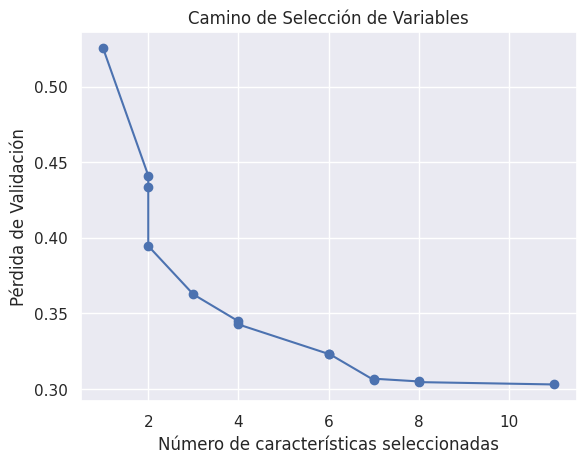

In [ ]:
# Perdida segun numero de variables seleccionadas (18 min.)

import matplotlib.pyplot as plt

# Obtiene las variables y los datos del camino de regularización
feats, path_data = model.get_regularization_path(X_train, y_train, init_reg_param=0.01)

# Graficar la pérdida de validación vs el número de características retenidas
plt.plot(path_data["num_feats"], path_data["val_loss"], marker='o', color='b')
plt.xlabel("Número de características seleccionadas")
plt.ylabel("Pérdida de Validación")
plt.title("Camino de Selección de Variables")
plt.show()

In [ ]:
# Por método del codo se elige "reg = 0.1"

# Entrenar modelo y seleccionar variables con parametro "reg = 0.1"

# Juntar datos de entrenamiento y validación
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

In [ ]:
# Modelo con "reg = 0.1" sin interacciones (2 min.)

from dnamite.models import DNAMiteBinaryClassifier

model = DNAMiteBinaryClassifier(
    random_state=1,
    device=device,
    num_pairs=0
)

model.select_features(
    X_train_final,
    y_train_final,
    reg_param=0.1,
    select_pairs=False
)

In [ ]:
# Mostrar variables seleccionadas
print("Número de variables:", len(model.selected_feats_))
print("Variables seleccionadas:", model.selected_feats_)

Número de variables: 7
Variables seleccionadas: ['age', 'education_num', 'occupation', 'relationship', 'capital_gain', 'capital_loss', 'hours_per_week']


# Modelo con variables seleccionadas

In [ ]:
# Ajustar el modelo (4 min.)
# Al llamar a fit() tras select_features(), dnamite entrenará usando automáticamente solo el subconjunto elegido
model.fit(X_train_final, y_train_final)

# Predicciones y evaluación en el conjunto de prueba
# probabilidades usando predict_proba
probs_NAM = model.predict_proba(X_test)

# Umbral de 0.5 para asignar las clases binarias
predicts_NAM = (probs_NAM > 0.5).astype(int)

[WARNING] Found selected features. Using only those features.


In [ ]:
# Calcular métricas y matriz de confusión
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

auc_test = roc_auc_score(y_test, probs_NAM)
accuracy_test = accuracy_score(y_test, predicts_NAM)
mc_nam = confusion_matrix(y_test, predicts_NAM)

# Resultados

In [ ]:
# AUC y Accuracy

print(f"\n--- Resultados del Modelo NAM ---")
print(f"AUC en Test: {auc_test:.4f}")
print(f"Accuracy en Test: {accuracy_test:.4f}")


--- Resultados del Modelo NAM ---
AUC en Test: 0.9270
Accuracy en Test: 0.8707


In [ ]:
# Matriz de confusion

print("\nMatriz de Confusión (Real vs Predicho):")
print(mc_nam)


Matriz de Confusión (Real vs Predicho):
[[7069  435]
 [ 828 1437]]


# Importancia de variables

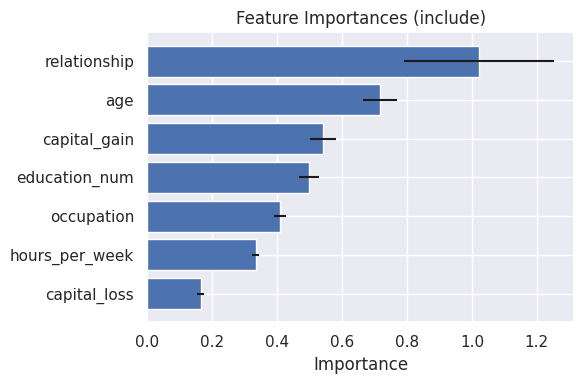

In [ ]:
model.plot_feature_importances()

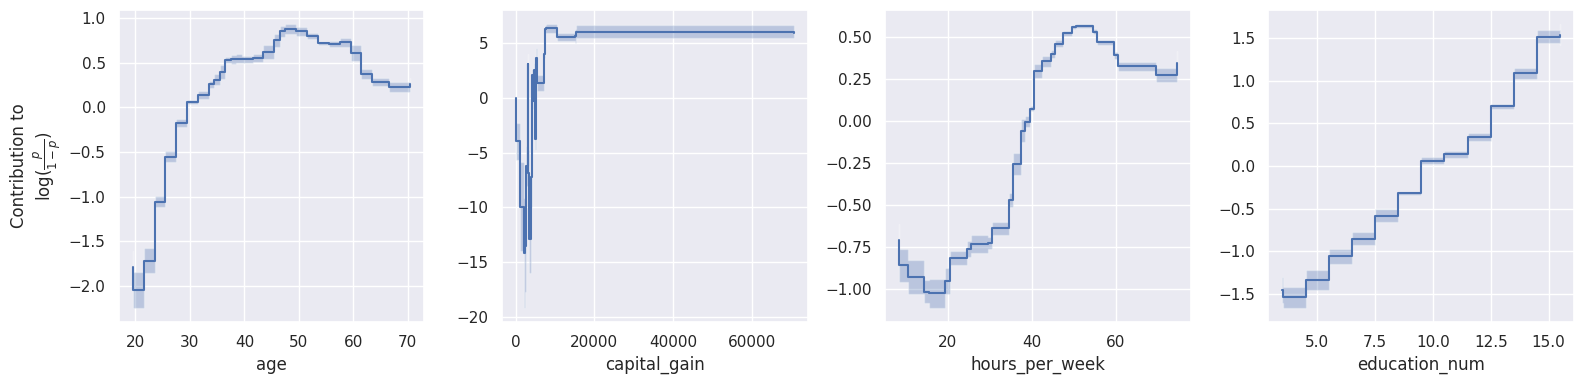

In [ ]:
# Continuas
model.plot_shape_function(['age', 'capital_gain', 'hours_per_week', 'education_num'])

Podemos ver en el gráfico de la variable $\texttt{age}$ que esta tiene una relación no lineal con la respuesta ($\texttt{Ingreso}$). Personas menores de 20 años tienen menor probabilidad de tener ingresos altos.
La probabilidad de poseer altos ingresos aumenta rápidamente entre los 25 y 45 años. Después de los 50 años el efecto se estabiliza y luego disminuye ligeramente cuando se cumplen los 60 años.

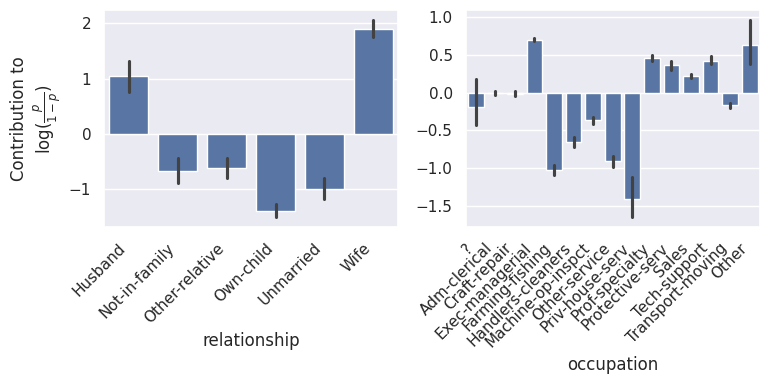

In [ ]:
# Categoricas
model.plot_shape_function(['relationship', 'occupation'])

Podemos ver que el coeficiente asociado para la categoría $\texttt{Wife}$ de la variable $\texttt{relationship}$ es de aproximadamente 1.9, como $\exp(1.9) \approx 6.7$, entonces podemos afirmar que una persona que sea $\textit{esposa}$ de alguien, tiene 6.7 veces mayor chance de poseer ingresos por encima de los 50K respecto a alguien que no lo sea.

# Exportar probabilidades para Curva ROC

Exportemos lo que se encuentra en `probs_NAM` para comparar las áreas bajo las curvas ROC de los modelos ajustados **MLP**, **GLM**, **GAM** y **NAM**.

Para ver la comparación, ir al archivo $\texttt{GLM_GAM_MLP.html}$ o al informe del estudio en el GitHub (https://github.com/HernanSV/Redes_Neuronales).

In [ ]:
# Exportar vector de probabilides probs_NAM a .csv

pd.Series(probs_NAM).to_csv("probs_NAM.csv", index=False, header=False)